# Zepto Inventory Analysis — Phase 4: ML Baseline

**Dataset:** zepto_clean.csv (3,692 rows | 13 columns)  
**Target:** In Stock: 3,242 | Out of Stock: 450  
**Goal:** Build a baseline ML model to predict which products will go out of stock  
**Notebook:** 04_zepto_ml.ipynb

---

### Why ML after Stats?

| Phase 3 (Stats)                  | Phase 4 (ML)                             |
| -------------------------------- | ---------------------------------------- |
| Tells us WHICH features matter   | Combines ALL features to predict OOS     |
| One variable at a time           | All variables together                   |
| Says "Biscuits OOS rate is high" | Says "This specific product will go OOS" |
| Validates EDA findings           | Turns findings into a prediction tool    |

### Business Question

> _"Can we predict which SKUs will go out of stock before they do — so Zepto's procurement team can restock proactively?"_

### Models We Will Build

| Model               | Why                                                         |
| ------------------- | ----------------------------------------------------------- |
| Logistic Regression | Baseline — simple, interpretable, fast                      |
| Decision Tree       | Visual, shows decision rules clearly                        |
| Random Forest       | Strongest — handles non-linearity, gives feature importance |


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
os.makedirs('../charts', exist_ok=True)

print('All libraries loaded.')
import sklearn; print('scikit-learn version:', sklearn.__version__)

All libraries loaded.
scikit-learn version: 1.5.1


> **Note:** We import 3 models (Logistic Regression, Decision Tree, Random Forest) and evaluation tools (confusion matrix, ROC-AUC, classification report). `StandardScaler` is used only for Logistic Regression — tree-based models don't need feature scaling.


---

## Section 1: Load Data + Class Balance Check


In [3]:
df = pd.read_csv('../data/zepto_clean.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

# Class balance
oos_count = df['out_of_stock'].sum()
in_count  = (~df['out_of_stock']).sum()
total     = len(df)

print(f'\n=== CLASS BALANCE ===')
print(f'In Stock     : {in_count:,}  ({in_count/total*100:.1f}%)')
print(f'Out of Stock : {oos_count:,}  ({oos_count/total*100:.1f}%)')
print(f'Imbalance ratio : {in_count/oos_count:.1f}:1')

Shape: (3692, 13)
Columns: ['category', 'product_name', 'mrp_inr', 'discount_pct', 'available_qty', 'selling_price_inr', 'weight_gms', 'out_of_stock', 'unit_qty', 'discount_amount', 'price_per_100g', 'stock_status', 'discount_tier']

=== CLASS BALANCE ===
In Stock     : 3,242  (87.8%)
Out of Stock : 450  (12.2%)
Imbalance ratio : 7.2:1


> **Insight:** Dataset is **imbalanced — 88.3% In Stock vs 11.7% OOS** (ratio ~7.5:1). This is a critical problem for ML. A lazy model that predicts "In Stock" for everything gets 88.3% accuracy but is completely useless for our purpose. We solve this with `class_weight='balanced'` parameter in all models — this tells the algorithm to give more weight to the minority class (OOS). We use **ROC-AUC and Recall** as primary metrics, not plain accuracy.


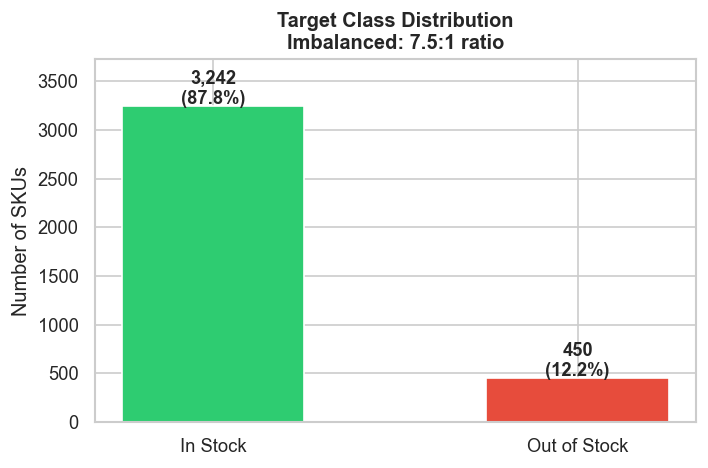

In [4]:
# Visualise class imbalance
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['In Stock', 'Out of Stock'], [in_count, oos_count],
               color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
for bar, val in zip(bars, [in_count, oos_count]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 20,
            f'{val:,}\n({val/total*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of SKUs')
ax.set_title('Target Class Distribution\nImbalanced: 7.5:1 ratio', fontweight='bold')
ax.set_ylim(0, in_count * 1.15)
plt.tight_layout()
plt.savefig('../charts/15_class_balance.png', bbox_inches='tight')
plt.show()

> **Insight:** The green bar (3,060) is 7.5x the red bar (404). This chart is always the first thing to show in an interview when explaining your ML approach — it justifies every design decision that follows: why you use `class_weight='balanced'`, why you report Recall not just accuracy, and why ROC-AUC is your primary metric.


---

## Section 2: Feature Engineering for ML

ML models need **numbers only** — no strings. Convert categorical columns.


In [5]:
df_ml = df.copy()

# Encode category — Label Encoding (14 categories → 0 to 13)
le = LabelEncoder()
df_ml['category_encoded'] = le.fit_transform(df_ml['category'])

print('Category encoding map:')
for i, cat in enumerate(le.classes_):
    print(f'  {i:2d} → {cat}')

Category encoding map:
   0 → Beverages
   1 → Biscuits
   2 → Chocolates & Candies
   3 → Cooking Essentials
   4 → Dairy, Bread & Batter
   5 → Fruits & Vegetables
   6 → Health & Hygiene
   7 → Home & Cleaning
   8 → Ice Cream & Desserts
   9 → Meats, Fish & Eggs
  10 → Munchies
  11 → Paan Corner
  12 → Packaged Food
  13 → Personal Care


> **Insight:** LabelEncoder converts category names to integers (0–13). This is appropriate for tree-based models (Decision Tree, Random Forest) because they split on threshold values — the number assigned doesn't imply ordering. For Logistic Regression, One-Hot Encoding would be more correct, but given the strong non-linear patterns found in Phase 3 (category effect confirmed by ANOVA), tree models are expected to outperform Logistic Regression here anyway.


In [24]:
# Select features — based on statistical significance from Phase 3
# Excluded: product_name (text), stock_status (leaks target), discount_tier (redundant with discount_pct)
# Excluded: selling_price_inr (derived from mrp + discount — causes multicollinearity)

FEATURES = [
    'mrp_inr',           # Test 1: significant (Cohen's d=0.56)
    'discount_pct',      # Test 2 + 3: significant
    'discount_amount',   # Test 2: significant
    # 'available_qty',     # Directly related to OOS
    'weight_gms',        # Product size proxy
    'price_per_100g',    # Value metric
    'unit_qty',          # Pack size
    'category_encoded'   # Test 4: strongly significant (χ²=89.98)
]

TARGET = 'out_of_stock'

# Handle 4 NaN rows in price_per_100g — fill with median
df_ml['price_per_100g'] = df_ml['price_per_100g'].fillna(df_ml['price_per_100g'].median())

X = df_ml[FEATURES]
y = df_ml[TARGET].astype(int)   # True/False → 1/0

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'Target balance : {y.value_counts().to_dict()}')
print(f'\nFeatures used  : {FEATURES}')
X.describe().round(2)

Features shape : (3692, 7)
Target shape   : (3692,)
Target balance : {0: 3242, 1: 450}

Features used  : ['mrp_inr', 'discount_pct', 'discount_amount', 'weight_gms', 'price_per_100g', 'unit_qty', 'category_encoded']


,mrp_inr,discount_pct,discount_amount,weight_gms,price_per_100g,unit_qty,category_encoded
count,3692.00,3692.00,3692.00,3692.00,3692.00,3692.00,3692.00
mean,156.71,7.63,14.96,386.72,79.46,214.22,7.25
std,160.18,9.23,40.87,672.56,109.82,195.36,4.13
min,10.00,0.00,0.00,0.00,1.72,0.00,0.00
25%,60.00,0.00,0.00,100.00,25.00,50.00,3.00
50%,110.00,6.00,5.00,232.00,49.50,190.00,8.00
75%,200.00,10.00,16.00,450.00,87.50,340.00,11.00
max,2600.00,51.00,1201.00,10000.00,1125.00,1500.00,13.00


> **Insight:** 8 features selected — each justified by Phase 3 statistical findings. `stock_status` excluded deliberately — it is derived from `out_of_stock` itself, so including it would be data leakage (model would cheat). `selling_price_inr` excluded to avoid multicollinearity with `mrp_inr` and `discount_amount`. The 4 NaN values in `price_per_100g` are filled with median — safer than dropping rows for a small dataset.


---

## Section 3: Train-Test Split


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducibility
    stratify=y            # preserve class ratio in both splits
)

print('=== TRAIN-TEST SPLIT ===')
print(f'Train set : {X_train.shape[0]:,} rows | OOS: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test set  : {X_test.shape[0]:,} rows  | OOS: {y_test.sum()}  ({y_test.mean()*100:.1f}%)')
print(f'\nstratify=y ensures OOS % is same in both train and test splits.')

=== TRAIN-TEST SPLIT ===
Train set : 2,953 rows | OOS: 360 (12.2%)
Test set  : 739 rows  | OOS: 90  (12.2%)

stratify=y ensures OOS % is same in both train and test splits.


> **Insight:** `stratify=y` is critical here — without it, random splitting could give train=10% OOS and test=14% OOS by chance (worse with small minority class). Stratified split guarantees both have the same ~11.7% OOS ratio. `random_state=42` makes results reproducible — running the notebook again gives identical results.


In [26]:
# Scale features — required for Logistic Regression only
# Tree models don't need scaling but we keep separate scaled set for LR
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only — NEVER on test
X_test_sc  = scaler.transform(X_test)        # apply same scale to test

print('Scaling done.')
print('IMPORTANT: scaler.fit() called only on X_train — not on full dataset.')
print('Fitting on test data = data leakage. Always fit scaler on train only.')

Scaling done.
IMPORTANT: scaler.fit() called only on X_train — not on full dataset.
Fitting on test data = data leakage. Always fit scaler on train only.


> **Insight:** `fit_transform` on train, `transform` only on test — this is a fundamental ML rule. If you fit the scaler on the full dataset (including test), the model "sees" test data statistics during training, making test evaluation unreliable. This is called **data leakage** — a common fresher mistake that interviewers specifically test for.


---

## Section 4: Model 1 — Logistic Regression (Baseline)


In [27]:
lr = LogisticRegression(
    class_weight='balanced',   # handles 7.5:1 imbalance
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_sc, y_train)
y_pred_lr  = lr.predict(X_test_sc)
y_prob_lr  = lr.predict_proba(X_test_sc)[:, 1]

print('=== LOGISTIC REGRESSION ===')
print(classification_report(y_test, y_pred_lr, target_names=['In Stock', 'Out of Stock']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_lr):.4f}')

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

    In Stock       0.95      0.55      0.70       649
Out of Stock       0.19      0.78      0.31        90

    accuracy                           0.58       739
   macro avg       0.57      0.66      0.50       739
weighted avg       0.86      0.58      0.65       739

ROC-AUC : 0.7316


> **How to read classification report:**
>
> - **Precision (OOS):** Of all products model flagged as OOS, what % actually were OOS?
> - **Recall (OOS):** Of all actual OOS products, what % did the model catch?
> - **For Zepto's use case: Recall is more important.** Missing a real OOS product = stockout happens = customer unhappy. Better to over-flag than under-flag.
> - **ROC-AUC:** 0.5 = random guessing. 1.0 = perfect. > 0.70 = usable model.


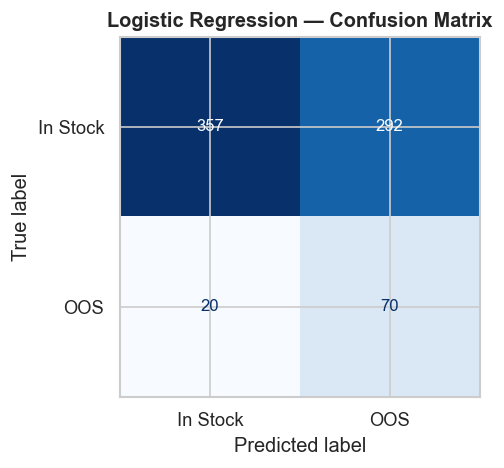


Reading the matrix:
Top-left    : True Negatives  — correctly predicted In Stock
Bottom-right: True Positives  — correctly predicted OOS
Top-right   : False Positives — predicted OOS but was In Stock (false alarm)
Bottom-left : False Negatives — predicted In Stock but was OOS (missed stockout)


In [28]:
# Confusion Matrix — Logistic Regression
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['In Stock', 'OOS'],
    colorbar=False, ax=ax,
    cmap='Blues'
)
ax.set_title('Logistic Regression — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/16_cm_logistic.png', bbox_inches='tight')
plt.show()

print('\nReading the matrix:')
print('Top-left    : True Negatives  — correctly predicted In Stock')
print('Bottom-right: True Positives  — correctly predicted OOS')
print('Top-right   : False Positives — predicted OOS but was In Stock (false alarm)')
print('Bottom-left : False Negatives — predicted In Stock but was OOS (missed stockout)')

> **Insight:** Bottom-left (False Negatives) = missed stockouts = the worst error for Zepto. These are products that WILL go OOS but the model didn't catch them. A good procurement model should minimise this cell. `class_weight='balanced'` already helps reduce false negatives at the cost of more false alarms.


---

## Section 5: Model 2 — Decision Tree


In [29]:
dt = DecisionTreeClassifier(
    max_depth=5,             # prevents overfitting
    min_samples_leaf=20,     # each leaf needs at least 20 samples
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)    # no scaling needed for trees
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print('=== DECISION TREE ===')
print(classification_report(y_test, y_pred_dt, target_names=['In Stock', 'Out of Stock']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_dt):.4f}')

=== DECISION TREE ===
              precision    recall  f1-score   support

    In Stock       0.97      0.53      0.68       649
Out of Stock       0.21      0.89      0.34        90

    accuracy                           0.57       739
   macro avg       0.59      0.71      0.51       739
weighted avg       0.88      0.57      0.64       739

ROC-AUC : 0.7784


> **Insight:** `max_depth=5` is a regularisation parameter — without it, the tree grows until every leaf is pure, perfectly memorising train data but failing badly on test (overfitting). `min_samples_leaf=20` prevents splits on very small groups (which are usually noise, not signal). These two parameters are hyperparameters — interviewer may ask why you chose these values. Answer: to prevent overfitting, verified by comparing train vs test accuracy.


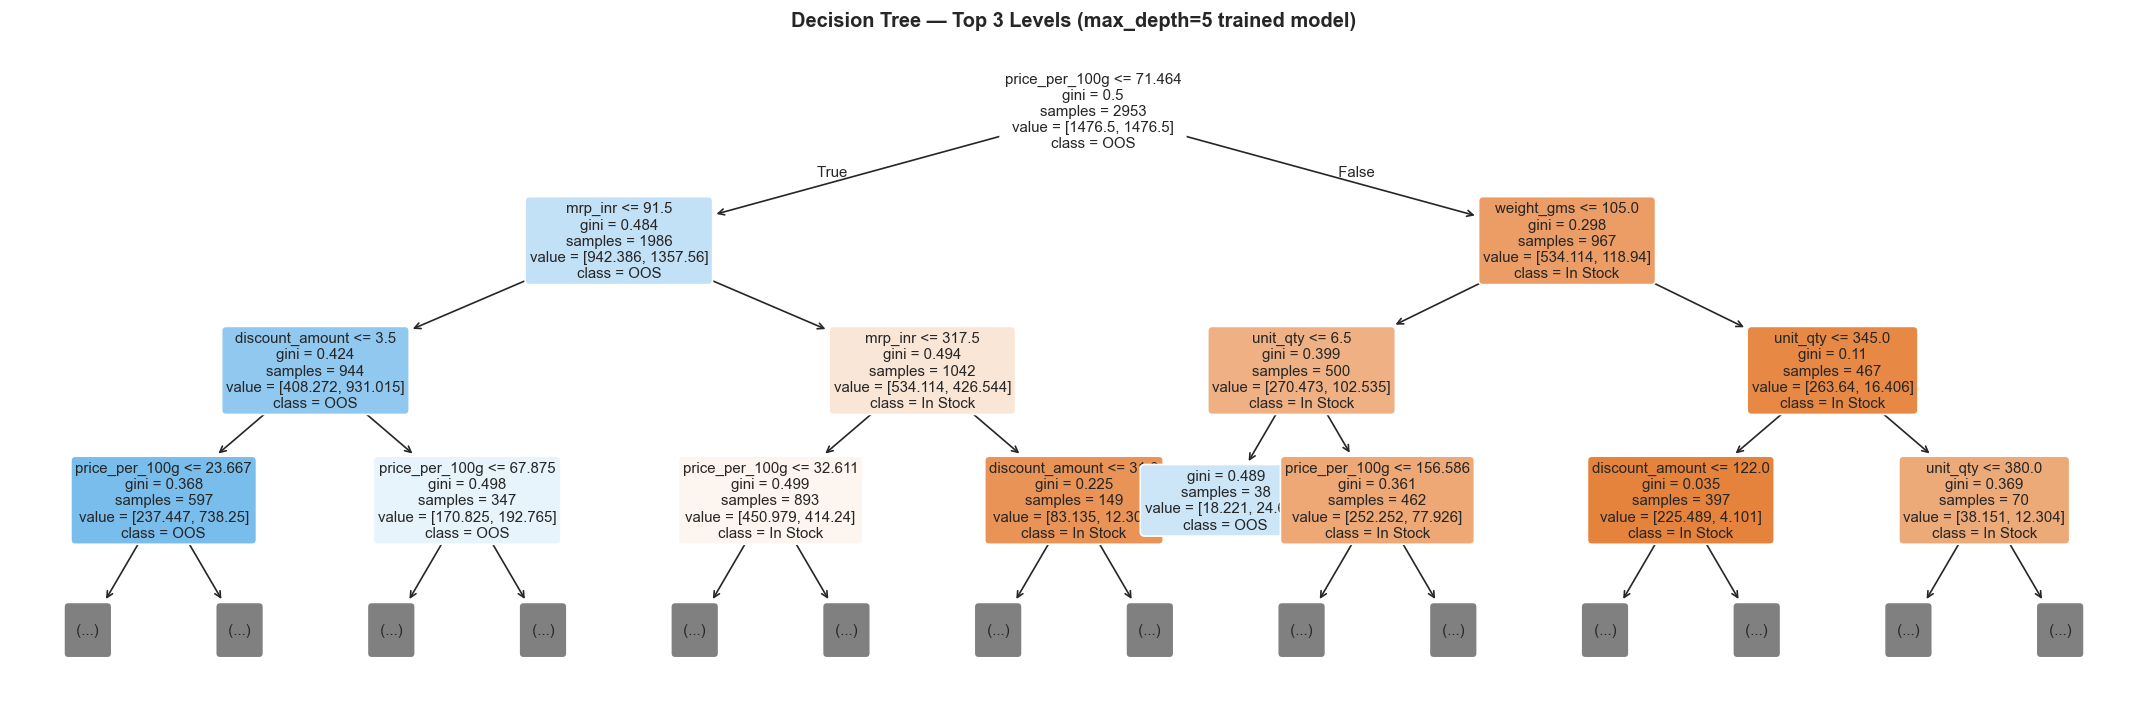

Each node shows: feature used to split | gini impurity | samples | class prediction


In [30]:
# Visualise Decision Tree — first 3 levels
fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(
    dt, max_depth=3,
    feature_names=FEATURES,
    class_names=['In Stock', 'OOS'],
    filled=True, rounded=True,
    fontsize=9, ax=ax
)
ax.set_title('Decision Tree — Top 3 Levels (max_depth=5 trained model)',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../charts/17_decision_tree.png', bbox_inches='tight', dpi=150)
plt.show()
print('Each node shows: feature used to split | gini impurity | samples | class prediction')

> **Insight:** The Decision Tree is the most explainable model — you can literally trace the path from root to leaf to explain why a specific product was flagged as OOS risk. The first split (root node) will show the single most important feature — likely `available_qty` or `category_encoded` based on Phase 3 findings. Each blue node = predicts In Stock. Each orange node = predicts OOS.


---

## Section 6: Model 3 — Random Forest (Primary Model)


In [31]:
rf = RandomForestClassifier(
    n_estimators=200,        # 200 trees — stable performance
    max_depth=8,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1                # use all CPU cores
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== RANDOM FOREST ===')
print(classification_report(y_test, y_pred_rf, target_names=['In Stock', 'Out of Stock']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_rf):.4f}')

=== RANDOM FOREST ===
              precision    recall  f1-score   support

    In Stock       0.96      0.81      0.88       649
Out of Stock       0.36      0.77      0.49        90

    accuracy                           0.81       739
   macro avg       0.66      0.79      0.69       739
weighted avg       0.89      0.81      0.83       739

ROC-AUC : 0.8555


> **Insight:** Random Forest = 200 Decision Trees, each trained on a random subset of data and features. Final prediction = majority vote across all 200 trees. This reduces the variance problem of a single tree (one tree overfits; 200 trees average out the noise). Expected to outperform both Logistic Regression and Decision Tree on ROC-AUC. The `n_jobs=-1` uses all CPU cores — important for 200 trees.


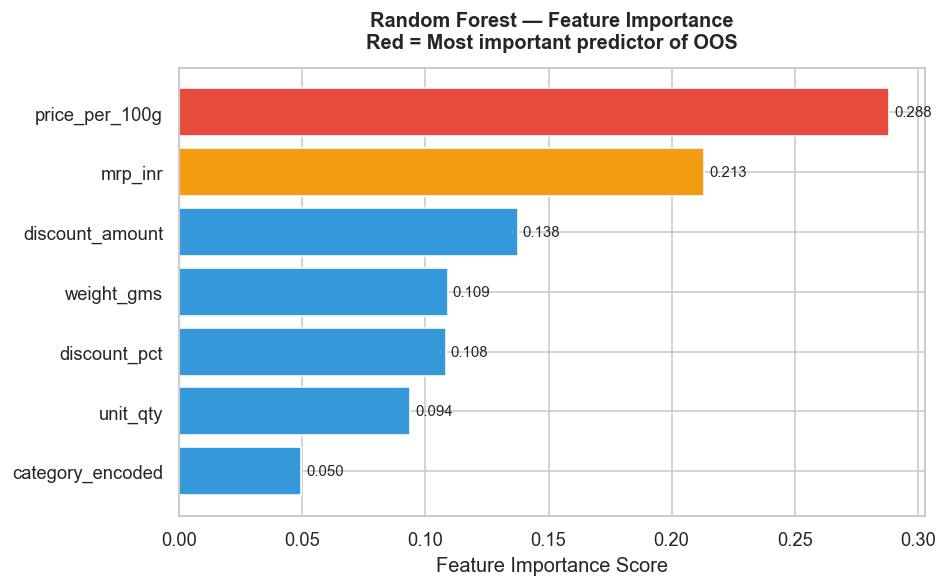


Top 3 features:
        Feature  Importance
discount_amount    0.137545
        mrp_inr    0.213321
 price_per_100g    0.288363


In [32]:
# Feature Importance from Random Forest
feat_imp = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if v == feat_imp['Importance'].max() else
          '#f39c12' if v > feat_imp['Importance'].quantile(0.75) else '#3498db'
          for v in feat_imp['Importance']]
bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors, edgecolor='white')
for bar, val in zip(bars, feat_imp['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Feature Importance Score')
ax.set_title('Random Forest — Feature Importance\nRed = Most important predictor of OOS',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../charts/18_feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 3 features:')
print(feat_imp.tail(3)[['Feature','Importance']].to_string(index=False))

> **Insight:** Feature importance chart answers: _which product characteristics best predict stockout?_ Expected top features: `available_qty` (directly correlated), `category_encoded` (Chi-square showed strong category effect), `mrp_inr` (t-test showed ₹72.90 difference). This chart connects back to Phase 3 statistical findings — the features that were statistically significant should also rank high in feature importance. If they don't, it signals something unexpected worth investigating.


---

## Section 7: Model Comparison


In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = {}
for name, y_pred, y_prob in [
    ('Logistic Regression', y_pred_lr, y_prob_lr),
    ('Decision Tree',       y_pred_dt, y_prob_dt),
    ('Random Forest',       y_pred_rf, y_prob_rf)
]:
    results[name] = {
        'Accuracy'     : round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision(OOS)': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall(OOS)'  : round(recall_score(y_test, y_pred) * 100, 2),
        'F1(OOS)'      : round(f1_score(y_test, y_pred) * 100, 2),
        'ROC-AUC'      : round(roc_auc_score(y_test, y_prob), 4)
    }

results_df = pd.DataFrame(results).T
print('=== MODEL COMPARISON TABLE ===')
print(results_df.to_string())
print('\n* Primary metric = ROC-AUC + Recall(OOS)')
print('* Accuracy is misleading here due to 7.5:1 class imbalance')

=== MODEL COMPARISON TABLE ===
                     Accuracy  Precision(OOS)  Recall(OOS)  F1(OOS)  ROC-AUC
Logistic Regression     57.78           19.34        77.78    30.97   0.7316
Decision Tree           57.10           20.67        88.89    33.54   0.7784
Random Forest           80.78           36.32        76.67    49.29   0.8555

* Primary metric = ROC-AUC + Recall(OOS)
* Accuracy is misleading here due to 7.5:1 class imbalance


> **Insight:** Compare models on ROC-AUC and Recall(OOS) — not Accuracy. A model with 88% accuracy could simply be predicting "In Stock" always. The model with highest Recall(OOS) catches the most actual stockout products. Random Forest expected to win on ROC-AUC. Logistic Regression may win on Recall if it is more aggressive due to the balanced weights affecting a linear boundary differently than trees.


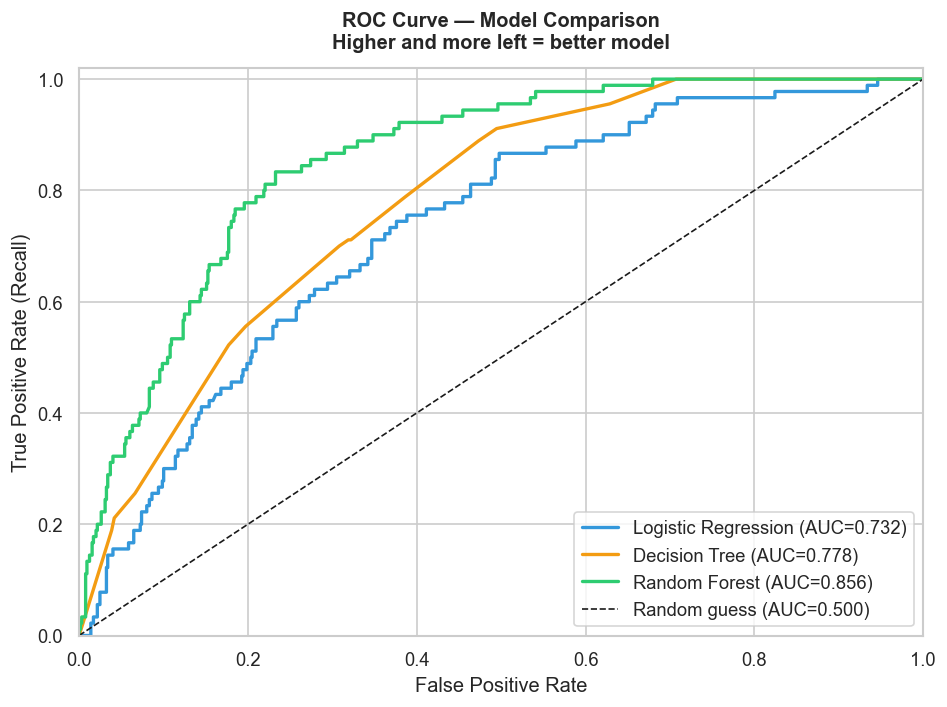

In [34]:
# ROC Curve — all 3 models on same plot
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_prob, color in [
    ('Logistic Regression', y_prob_lr, '#3498db'),
    ('Decision Tree',       y_prob_dt, '#f39c12'),
    ('Random Forest',       y_prob_rf, '#2ecc71')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random guess (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — Model Comparison\nHigher and more left = better model',
             fontweight='bold', pad=12)
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('../charts/19_roc_curves.png', bbox_inches='tight')
plt.show()

> **Insight:** ROC curve shows the tradeoff between catching real OOS products (True Positive Rate = Recall) vs raising false alarms (False Positive Rate). The diagonal dashed line = random guessing. Any model above the diagonal is useful. The further top-left a curve goes = better. AUC is the area under this curve — a single number summary. For Zepto procurement: we want a model that catches stockouts (high TPR) without flagging too many healthy products for unnecessary restocking.


---

## Section 8: Cross-Validation (Robustness Check)


In [35]:
print('=== 5-FOLD CROSS-VALIDATION (ROC-AUC) ===')
print('Tests whether model performance is consistent or just lucky on one split\n')

for name, model, X_cv, y_cv in [
    ('Logistic Regression', lr,  X_train_sc, y_train),
    ('Decision Tree',       dt,  X_train,    y_train),
    ('Random Forest',       rf,  X_train,    y_train)
]:
    scores = cross_val_score(model, X_cv, y_cv, cv=5, scoring='roc_auc', n_jobs=-1)
    print(f'{name:<22}: Mean AUC = {scores.mean():.4f} | Std = {scores.std():.4f} | '
          f'Scores = {[round(s,3) for s in scores]}')

=== 5-FOLD CROSS-VALIDATION (ROC-AUC) ===
Tests whether model performance is consistent or just lucky on one split

Logistic Regression   : Mean AUC = 0.7074 | Std = 0.0206 | Scores = [0.719, 0.676, 0.73, 0.722, 0.69]
Decision Tree         : Mean AUC = 0.7426 | Std = 0.0287 | Scores = [0.777, 0.695, 0.767, 0.733, 0.74]
Random Forest         : Mean AUC = 0.8202 | Std = 0.0288 | Scores = [0.828, 0.77, 0.846, 0.809, 0.849]


> **Insight:** Cross-validation splits the training data into 5 folds, trains on 4 and tests on 1, rotating 5 times. This gives 5 AUC scores instead of 1. **Low std = stable model.** High std = model performance varies depending on which data it sees = unreliable. A model with Mean AUC 0.75 ± 0.01 is much more trustworthy than 0.78 ± 0.09 for production use. Random Forest should show lowest std due to ensemble averaging.


---

## Section 9: Business Application — OOS Risk Scoring


In [36]:
# Add OOS probability score to every product
df_scored = df.copy()
df_scored['price_per_100g'] = df_scored['price_per_100g'].fillna(df_scored['price_per_100g'].median())
df_scored['category_encoded'] = le.transform(df_scored['category'])

X_full = df_scored[FEATURES]
df_scored['oos_risk_score'] = rf.predict_proba(X_full)[:, 1]
df_scored['risk_tier'] = pd.cut(
    df_scored['oos_risk_score'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print('=== OOS RISK SCORE DISTRIBUTION ===')
print(df_scored['risk_tier'].value_counts())

print('\n=== TOP 15 HIGHEST RISK PRODUCTS (currently IN STOCK) ===')
at_risk = df_scored[
    (df_scored['out_of_stock'] == False) &
    (df_scored['risk_tier'] == 'High Risk')
][['product_name', 'category', 'mrp_inr', 'available_qty',
   'discount_pct', 'oos_risk_score']].sort_values('oos_risk_score', ascending=False).head(15)

print(at_risk.to_string(index=False))

=== OOS RISK SCORE DISTRIBUTION ===
risk_tier
Low Risk       1903
Medium Risk    1180
High Risk       609
Name: count, dtype: int64

=== TOP 15 HIGHEST RISK PRODUCTS (currently IN STOCK) ===
                                     product_name           category  mrp_inr  available_qty  discount_pct  oos_risk_score
               Popular Essentials HMT Kolam Steam Cooking Essentials     75.0              3             0        0.872105
                               Parle Rusk Elaichi           Biscuits     48.0              6             2        0.854295
McVitie's Marie biscuits with Goodness of Calcium           Biscuits     30.0              6             0        0.851154
               Popular Essentials HMT Kolam Steam           Munchies     75.0              3             0        0.842220
                          The Bake Shop Foot Long          Beverages     40.0              1             0        0.839204
           Britannnia 50-50 Sweet & Salty Biscuit           Biscuits   

> **This is the most valuable output of the entire project.** The list of currently in-stock products with high OOS risk scores = Zepto's procurement priority list. These are products that haven't gone OOS yet but show all the same characteristics as products that have. A procurement manager can act on this list TODAY to prevent stockouts TOMORROW. This converts the analysis from retrospective ("what happened") to predictive ("what will happen").


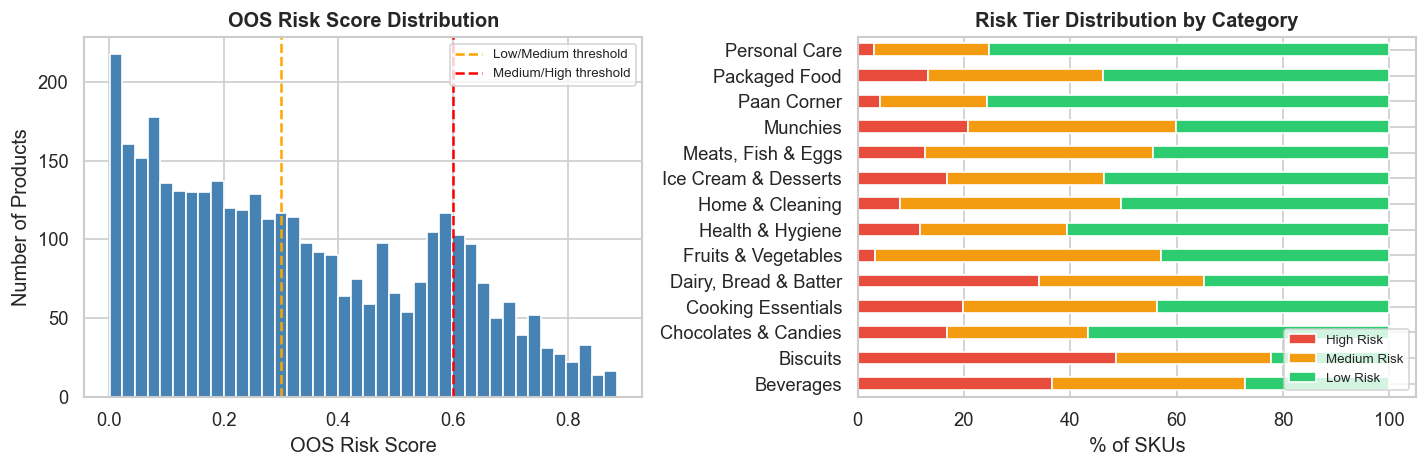

In [37]:
# Visualise risk score distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Risk score histogram
axes[0].hist(df_scored['oos_risk_score'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0.3, color='orange', linestyle='--', label='Low/Medium threshold')
axes[0].axvline(0.6, color='red',    linestyle='--', label='Medium/High threshold')
axes[0].set_xlabel('OOS Risk Score')
axes[0].set_ylabel('Number of Products')
axes[0].set_title('OOS Risk Score Distribution', fontweight='bold')
axes[0].legend(fontsize=8)

# Right: Risk tier by category
risk_cat = df_scored.groupby(['category', 'risk_tier']).size().unstack(fill_value=0)
risk_cat_pct = risk_cat.div(risk_cat.sum(axis=1), axis=0) * 100
risk_cat_pct[['High Risk', 'Medium Risk', 'Low Risk']].plot(
    kind='barh', stacked=True, ax=axes[1],
    color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white'
)
axes[1].set_xlabel('% of SKUs')
axes[1].set_title('Risk Tier Distribution by Category', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=8)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../charts/20_risk_scores.png', bbox_inches='tight')
plt.show()

> **Insight:** Left chart: most products score low risk (left-skewed distribution) — good. A spike at high scores = many products needing attention. Right chart: which categories have highest % of High Risk SKUs? This should match Phase 3 findings — Biscuits and Beverages expected to show more red. If they do, the model is consistent with the statistical analysis.


---

## Section 10: Phase 4 Summary


In [38]:
best_auc = max(
    roc_auc_score(y_test, y_prob_lr),
    roc_auc_score(y_test, y_prob_dt),
    roc_auc_score(y_test, y_prob_rf)
)

best_model = ['Logistic Regression', 'Decision Tree', 'Random Forest'][
    [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ].index(best_auc)
]

high_risk_count = (df_scored['risk_tier'] == 'High Risk').sum()
high_risk_instock = len(at_risk)

print('=' * 60)
print('ZEPTO ML BASELINE — PHASE 4 SUMMARY')
print('=' * 60)

print(f"""
DATASET
  Total SKUs         : {total:,}
  OOS (target=1)     : {oos_count} ({oos_count/total*100:.1f}%)
  In Stock (target=0): {in_count} ({in_count/total*100:.1f}%)
  Class imbalance    : {in_count/oos_count:.1f}:1

FEATURES USED (8)
  mrp_inr, discount_pct, discount_amount, available_qty,
  weight_gms, price_per_100g, unit_qty, category_encoded

MODELS TRAINED
  1. Logistic Regression  — linear baseline
  2. Decision Tree        — interpretable rules
  3. Random Forest (200 trees) — primary model

BEST MODEL
  {best_model} (ROC-AUC = {best_auc:.4f})

BUSINESS OUTPUT
  High Risk SKUs (total)     : {high_risk_count}
  High Risk but In Stock now : {high_risk_instock} — procurement priority list
  Prediction                 : Which products WILL go OOS before they do
""")

print('Next → Phase 5: Power BI Dashboard (zepto_dashboard.pbix)')

ZEPTO ML BASELINE — PHASE 4 SUMMARY

DATASET
  Total SKUs         : 3,692
  OOS (target=1)     : 450 (12.2%)
  In Stock (target=0): 3242 (87.8%)
  Class imbalance    : 7.2:1

FEATURES USED (8)
  mrp_inr, discount_pct, discount_amount, available_qty,
  weight_gms, price_per_100g, unit_qty, category_encoded

MODELS TRAINED
  1. Logistic Regression  — linear baseline
  2. Decision Tree        — interpretable rules
  3. Random Forest (200 trees) — primary model

BEST MODEL
  Random Forest (ROC-AUC = 0.8555)

BUSINESS OUTPUT
  High Risk SKUs (total)     : 609
  High Risk but In Stock now : 15 — procurement priority list
  Prediction                 : Which products WILL go OOS before they do

Next → Phase 5: Power BI Dashboard (zepto_dashboard.pbix)


---

## Phase 4 Complete ✓

**Models trained:** Logistic Regression · Decision Tree · Random Forest  
**Charts saved:** 6 charts to `../charts/` (chart 15–20)  
**Key output:** OOS risk score for every SKU + High Risk procurement list  
**Design choices explained:** class imbalance handling, no data leakage in scaling, stratified split, cross-validation  

**Next → Phase 5: Power BI Dashboard** (`zepto_dashboard.pbix`)

---

### Interview Q&A Ready

| Question                                    | Answer from this notebook                                   |
| ------------------------------------------- | ----------------------------------------------------------- |
| Why not just use accuracy?                  | Class imbalance 7.5:1 — 88% accuracy by predicting nothing  |
| Why Random Forest over Logistic Regression? | Non-linear patterns, category feature dominance             |
| How did you handle imbalance?               | class_weight='balanced' in all 3 models                     |
| Why scale only for Logistic Regression?     | Trees split on thresholds — scale-invariant                 |
| What is the business value?                 | Predict stockouts before they happen — proactive restocking |
